<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Imports-and-Constants" data-toc-modified-id="Imports-and-Constants-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Imports and Constants</a></span></li><li><span><a href="#Load-data" data-toc-modified-id="Load-data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load data</a></span><ul class="toc-item"><li><span><a href="#Load-the-loc_dict-(create-if-necessary)" data-toc-modified-id="Load-the-loc_dict-(create-if-necessary)-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Load the <code>loc_dict</code> (create if necessary)</a></span></li><li><span><a href="#Combine-to-pd.DataFrame" data-toc-modified-id="Combine-to-pd.DataFrame-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Combine to <code>pd.DataFrame</code></a></span></li></ul></li><li><span><a href="#Locations" data-toc-modified-id="Locations-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Locations</a></span><ul class="toc-item"><li><span><a href="#Basic-Location-Stats" data-toc-modified-id="Basic-Location-Stats-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Basic Location Stats</a></span></li></ul></li><li><span><a href="#Create-Data-Splits" data-toc-modified-id="Create-Data-Splits-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Create Data Splits</a></span><ul class="toc-item"><li><span><a href="#Create-country_indices-and-country_labels" data-toc-modified-id="Create-country_indices-and-country_labels-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Create <code>country_indices</code> and <code>country_labels</code></a></span></li><li><span><a href="#OOC-splits" data-toc-modified-id="OOC-splits-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>OOC splits</a></span></li><li><span><a href="#Incountry-splits" data-toc-modified-id="Incountry-splits-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Incountry splits</a></span></li><li><span><a href="#Urban-v.-Rural" data-toc-modified-id="Urban-v.-Rural-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Urban v. Rural</a></span></li></ul></li><li><span><a href="#Data-Analysis-by-Country" data-toc-modified-id="Data-Analysis-by-Country-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Data Analysis by Country</a></span><ul class="toc-item"><li><span><a href="#Size" data-toc-modified-id="Size-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Size</a></span></li><li><span><a href="#Wealthpooled" data-toc-modified-id="Wealthpooled-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Wealthpooled</a></span></li><li><span><a href="#Urban-v.-Rural" data-toc-modified-id="Urban-v.-Rural-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Urban v. Rural</a></span></li><li><span><a href="#Nightlights" data-toc-modified-id="Nightlights-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Nightlights</a></span></li><li><span><a href="#Households" data-toc-modified-id="Households-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>Households</a></span></li></ul></li><li><span><a href="#Data-Analysis-by-Split" data-toc-modified-id="Data-Analysis-by-Split-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Data Analysis by Split</a></span><ul class="toc-item"><li><span><a href="#Wealthpooled" data-toc-modified-id="Wealthpooled-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Wealthpooled</a></span></li><li><span><a href="#Urban-v.-Rural" data-toc-modified-id="Urban-v.-Rural-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Urban v. Rural</a></span></li><li><span><a href="#Nightlights" data-toc-modified-id="Nightlights-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Nightlights</a></span></li></ul></li><li><span><a href="#All-Zero-NL" data-toc-modified-id="All-Zero-NL-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>All-Zero NL</a></span></li><li><span><a href="#Visualize-Images" data-toc-modified-id="Visualize-Images-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Visualize Images</a></span><ul class="toc-item"><li><span><a href="#Highest-wealth" data-toc-modified-id="Highest-wealth-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Highest wealth</a></span></li><li><span><a href="#Lowest-wealth" data-toc-modified-id="Lowest-wealth-8.2"><span class="toc-item-num">8.2&nbsp;&nbsp;</span>Lowest wealth</a></span></li></ul></li></ul></div>

Prerequisites:
1. Run the first couple of sections from `models/baselines_dhs.ipynb` to create `data/dhs_image_hists.npz`

# Imports and Constants

Downloading Libraries

In [2]:
from collections import defaultdict
import os
import pickle
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from batchers import batcher1, dataset_constants
#from data_analysis.create_folds import create_folds, verify_folds
#from utils.geo_plot import setup_ax , plot_locs
from utils.general import colordisplay, load_npz
from utils.plot import boxplot_df, plot_image_by_band

/home/sagemaker-user/reproducible/nexus_experiment/lib/python3.6/site-packages/google/auth/crypt/_cryptography_rsa.py:22: CryptographyDeprecationWarning: Python 3.6 is no longer supported by the Python core team. Therefore, support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.6.
  import cryptography.exceptions


/home/sagemaker-user/reproducible/data/processed/nexus_tfrecords_processed/


Important Constants

In [3]:
#os.environ['CUDA_VISIBLE_DEVICES'] = ''

FOLDS = ['A', 'B', 'C', 'D', 'E']
SPLITS = ['train', 'val', 'test']
BAND_ORDER = ['BLUE', 'GREEN', 'RED', 'SWIR1', 'SWIR2', 'TEMP1', 'NIR', 'NIGHTLIGHTS']
DATASET = 'DHS_OOC_A'

COUNTRIES =["Brazil"]
print(COUNTRIES)
print(len(COUNTRIES))

['Brazil']
1


# Load data

Loading the .npz files

In [4]:
indicators = ["income","longevity","literacy"]
for label in indicators:
    file_path = f"/home/sagemaker-user/reproducible/data/processed/dhs_co_{label}.npz"
    print(f"para o Indicador {label}:")
    result = load_npz(file_path)
    image_hists = result['image_hists']
    labels = result['labels']

    locs = result['locs']
    years = result['years']
    nls_center = result["nls_center"]

    nls_mean = result['nls_mean']

    dmsp_mask = years < 2012
    viirs_mask = ~dmsp_mask
    

para o Indicador income:
image_hists: dtype=int64, shape=(23675, 8, 102)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
nls_center: dtype=float32, shape=(23675,)
nls_mean: dtype=float32, shape=(23675,)
para o Indicador longevity:
image_hists: dtype=int64, shape=(23675, 8, 102)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
nls_center: dtype=float32, shape=(23675,)
nls_mean: dtype=float32, shape=(23675,)
para o Indicador literacy:
image_hists: dtype=int64, shape=(23675, 8, 102)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
nls_center: dtype=float32, shape=(23675,)
nls_mean: dtype=float32, shape=(23675,)


## Load the `loc_dict` (create if necessary)

In [5]:
df_data = []
for label, loc, nl_mean, nl_center in zip(labels, locs, nls_mean, nls_center):
    lat, lon = loc   
            
    row = [lat, lon, label, nl_mean, nl_center]
    df_data.append(row)
df = pd.DataFrame.from_records(
    df_data,
    columns=['lat', 'lon', 'label', 'nl_mean', 'nl_center'])
print(df)

df.to_csv('df12_literacy.csv', index=False)


             lat        lon     label   nl_mean  nl_center
0      -8.580904 -41.285118  0.664332 -0.158284  -0.158284
1      -8.416358 -41.365967  0.712346 -0.158284  -0.158284
2      -8.498622 -41.285118  0.812670 -0.158284  -0.158284
3      -8.910205 -44.195660  0.716522 -0.144692  -0.158284
4      -8.827853 -44.195660  0.687544  0.564757   1.421355
...          ...        ...       ...       ...        ...
23670 -14.478227 -59.556850  0.869212  0.708057  -0.158284
23671 -14.562235 -59.476002  0.917413 -0.158284  -0.158284
23672 -14.478227 -59.476002  0.853558 -0.103542  -0.158284
23673 -14.562235 -59.395153  0.911802 -0.158284  -0.158284
23674 -14.478227 -59.395153  0.791484 -0.158284  -0.158284

[23675 rows x 5 columns]


`loc_dict` has the format:
```python
{
    (lat, lon): {
        'cluster': 1,
        'country': 'malawi',
        'country_year': 'malawi_2012',  # surveyID
        'households': 25,
        'urban': False,
        'wealth': -0.513607621192932,
        'wealthpooled': -0.732255101203918,
        'year': 2012
    }, ...
}
```

NOTE: `year` and `country_year` might differ in the year. `country_year` is the survey ID, which says which year the survey started. However, sometimes the DHS surveys cross the year-boundary, in which case `country_year` will remain the same but `year` will be the next year.

In [6]:
def create_loc_dict(loc_dict_path,csv_path,label):
    '''
    Args
    - loc_dict_path: str, path to save the loc_dict
    '''
    surveys_df = pd.read_csv(csv_path)
    nok = 0
    ok = 0
    #surveys_df.rename({'TYPE': 'urban'},
    #                 axis='columns', inplace=True)
    #surveys_df['urban'] = surveys_df['urban'] == 'URBAN'

    for col in ['lat', 'lon', label]:
        surveys_df[col] = surveys_df[col].astype(np.float32)
        surveys_df['country'] = (surveys_df['country']
                             .str.lower())


    loc_dict = {}
    for (lat, lon) in locs:
        loc = (lat, lon)        
        row = surveys_df.loc[(surveys_df['lat'] == lat) & (surveys_df['lon'] == lon), :]

        if len(row) != 1:
            nok += 1
            continue
        elif len(row) == 1:
            ok += 1
        else:
            raise Exception('Len Row > 1')
        row = row.iloc[0]


        #cy = '{c}_{y}'.format(c=row['country'], y=row['svyid'][-4:])

        assert loc not in loc_dict
        loc_dict[loc] = {
            'country': row['country'],
            'year': row['year']
        }

    with open(loc_dict_path, 'wb') as f:
        pickle.dump(loc_dict, f)
    print('s', ok)

Creating the Loc Dicts for each indicator

In [7]:
indicators = ["income","longevity","literacy"]
for i,label in enumerate(indicators):
    loc_dict_path = f'/home/sagemaker-user/reproducible/data/processed/loc_dict_brazil_2010_{label}.pkl'
    #csv_path = f'/home/sagemaker-user/reproducible/data/processed/dataset_clean.csv'
    csv_path = f'/home/sagemaker-user/reproducible/data/processed/clusters_data_9000.0km.csv'
    print(f"para o Indicador {label}:")

    #if not os.path.exists(loc_dict_path):
    create_loc_dict(loc_dict_path,csv_path,label)
    
    with open(loc_dict_path, 'rb') as f:
        loc_dict = pickle.load(f)
        #print(loc_dict)

para o Indicador income:
s 23477
para o Indicador longevity:
s 23477
para o Indicador literacy:
s 23477


## Combine to `pd.DataFrame`

Verifying the loc Dicts Files

In [8]:
indicators = ["income"]
for label in indicators:
    file_path = f"/home/sagemaker-user/reproducible/data/processed/dhs_co_{label}.npz"
    print(f"para o Indicador {label}:")
    result = load_npz(file_path)
    image_hists = result['image_hists']
    labels = result['labels']

    locs = result['locs']
    years = result['years']
    nls_center = result["nls_center"]

    nls_mean = result['nls_mean']

    dmsp_mask = years < 2012
    viirs_mask = ~dmsp_mask

para o Indicador income:
image_hists: dtype=int64, shape=(23675, 8, 102)
labels: dtype=float32, shape=(23675,)
locs: dtype=float32, shape=(23675, 2)
years: dtype=int32, shape=(23675,)
nls_center: dtype=float32, shape=(23675,)
nls_mean: dtype=float32, shape=(23675,)


In [9]:
df_data = []
for label, loc, nl_mean, nl_center in zip(labels, locs, nls_mean, nls_center):
    lat, lon = loc   
            
    row = [lat, lon, label, nl_mean, nl_center]
    df_data.append(row)
df = pd.DataFrame.from_records(
    df_data,
    columns=['lat', 'lon', 'label', 'nl_mean', 'nl_center'])
print(df)

df.to_csv('df12.csv', index=False)

             lat        lon     label   nl_mean  nl_center
0      -8.580904 -41.285118  0.335203 -0.158284  -0.158284
1      -8.416358 -41.365967  0.305859 -0.158284  -0.158284
2      -8.498622 -41.285118  0.354646 -0.158284  -0.158284
3      -8.910205 -44.195660  0.408251 -0.144692  -0.158284
4      -8.827853 -44.195660  0.434718  0.564757   1.421355
...          ...        ...       ...       ...        ...
23670 -14.478227 -59.556850  0.534529  0.708057  -0.158284
23671 -14.562235 -59.476002  0.588272 -0.158284  -0.158284
23672 -14.478227 -59.476002  0.517694 -0.103542  -0.158284
23673 -14.562235 -59.395153  0.582070 -0.158284  -0.158284
23674 -14.478227 -59.395153  0.449085 -0.158284  -0.158284

[23675 rows x 5 columns]


In [10]:
indicators = ["income"]
for i,label in enumerate(indicators):
    loc_dict_path = f'/home/sagemaker-user/reproducible/data/processed/loc_dict_brazil_2010_{label}.pkl'
    #csv_path = f'/home/sagemaker-user/reproducible/data/processed/dataset_clean.csv'
    csv_path = f'/home/sagemaker-user/reproducible/data/processed/clusters_data_9000.0km.csv'
    print(f"para o Indicador {label}:")
    print(loc_dict_path)

    if not os.path.exists(loc_dict_path):
        create_loc_dict(loc_dict_path,csv_path,label)
    
    with open(loc_dict_path, 'rb') as f:
        loc_dict = pickle.load(f)


para o Indicador income:
/home/sagemaker-user/reproducible/data/processed/loc_dict_brazil_2010_income.pkl


In [11]:
# !! 
# Criar o DataFrame garantindo que apenas as localizações válidas sejam incluídas
df_data = []
for label, loc, nl_mean, nl_center in zip(labels, locs, nls_mean, nls_center):
    lat, lon = loc
    if (lat, lon) in loc_dict:
        loc_info = loc_dict[(lat, lon)]
        country = loc_info['country']
        year = loc_info['year']
        row = [lat, lon, label, country, year, nl_mean, nl_center]
        df_data.append(row)
    else:
        print(f"Localização não encontrada no dicionário: {loc}")

df = pd.DataFrame.from_records(
    df_data,
    columns=['lat', 'lon', 'label', 'country', 'year', 'nl_mean', 'nl_center']
)

# Verificar se o DataFrame contém as colunas esperadas e se tem tamanho consistente
print(df.head())
print(f"Tamanho do DataFrame: {df.shape}")

# Salvar o DataFrame para verificação adicional se necessário
df.to_csv('df_verificado.csv', index=False)

Localização não encontrada no dicionário: [ -8.498622 -41.28512 ]
Localização não encontrada no dicionário: [ -8.827853 -44.033962]
Localização não encontrada no dicionário: [ -8.745519 -44.11481 ]
Localização não encontrada no dicionário: [-18.892916 -46.378567]
Localização não encontrada no dicionário: [-18.378237 -49.935894]
Localização não encontrada no dicionário: [-14.8985815 -46.782806 ]
Localização não encontrada no dicionário: [ -7.6767235 -43.79142  ]
Localização não encontrada no dicionário: [-16.164562 -44.357357]
Localização não encontrada no dicionário: [-12.30429  -46.459415]
Localização não encontrada no dicionário: [-21.141813 -48.318928]
Localização não encontrada no dicionário: [-22.54226 -50.66353]
Localização não encontrada no dicionário: [-16.758032 -56.727158]
Localização não encontrada no dicionário: [ -6.7744126 -42.0936   ]
Localização não encontrada no dicionário: [-16.673141 -42.659542]
Localização não encontrada no dicionário: [-15.066946 -49.28911 ]
Locali

In [12]:
# # marcação
# df_data = []
# for label, loc, nl_mean, nl_center in zip(labels, locs, nls_mean, nls_center):
#     try:
#         lat, lon = loc
#         loc_info = loc_dict[(lat, lon)]
#         country = loc_info['country']
#         year = loc_info['year']
#         row = [lat, lon, label, country, year, nl_mean, nl_center]
#         df_data.append(row)
#     except Exception as e:
#         continue
# df = pd.DataFrame.from_records(
#     df_data,
#     columns=['lat', 'lon', 'label', 'country', 'year', 'nl_mean', 'nl_center'])

In [13]:
with pd.option_context('display.max_rows', 30):
    display(df)
    
    df.to_csv('test244.csv', index=False)

,lat,lon,label,country,year,nl_mean,nl_center
0,-8.580904,-41.285118,0.335203,brazil,2010,-0.158284,-0.158284
1,-8.416358,-41.365967,0.305859,brazil,2010,-0.158284,-0.158284
2,-8.910205,-44.195660,0.408251,brazil,2010,-0.144692,-0.158284
3,-8.827853,-44.195660,0.434718,brazil,2010,0.564757,1.421355
4,-8.910205,-44.114811,0.421549,brazil,2010,0.047785,-0.158284
...,...,...,...,...,...,...,...
23472,-14.478227,-59.556850,0.534529,brazil,2010,0.708057,-0.158284
23473,-14.562235,-59.476002,0.588272,brazil,2010,-0.158284,-0.158284
23474,-14.478227,-59.476002,0.517694,brazil,2010,-0.103542,-0.158284
23475,-14.562235,-59.395153,0.582070,brazil,2010,-0.158284,-0.158284


# Stopped running the code at this point

# Locations

## Basic Location Stats

Lat. min: -24.937996, max: -2.364476
Lon. min: -60.688728, max: -35.221489

maximum side_lat: 0.060570
maximum side_lon: 0.066798


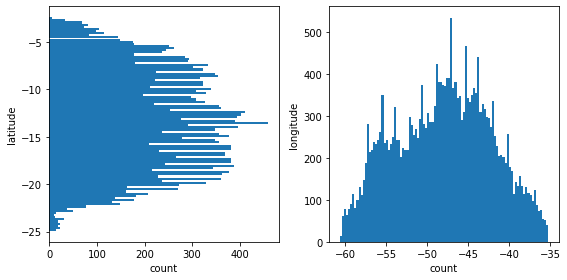

In [14]:
RADIUS_EARTH = 6356.7523  # in km, polar radius of Earth

def get_lon_for_distance(lat, d):
    '''Calculates the degrees longitude for some East-West distance at a given latitude.

    Makes (incorrect) assumption that Earth is a perfect sphere.
    Uses the smaller polar radius (instead of equatorial radius), so
        actual degrees longitude <= returned value

    Args
    - lat: numeric, latitude in degrees
    - d: numeric, distance in km

    Returns
    - lon: float, approximate degrees longitude
    '''
    lat = np.abs(lat) * np.pi / 180.0  # convert to radians
    r = RADIUS_EARTH * np.cos(lat)  # radius at the given lat
    lon = d / r
    lon = lon * 180.0 / np.pi  # convert to degrees
    return lon

def get_lat_for_distance(d):
    '''Calculates the degrees latitude for some North-South distance.

    Makes (incorrect) assumption that Earth is a perfect sphere.
    Uses the smaller polar radius (instead of equatorial radius), so
        actual degrees latitude <= returned value

    Args
    - d: numeric, distance in km

    Returns
    - lat: float, approximate degrees latitude
    '''
    lat = d / RADIUS_EARTH  # in radians
    lat = lat * 180.0 / np.pi  # convert to degrees
    return lat

def print_loc_stats(locs):
    '''
    Args
    - locs: np.array, shape [N, 2], each row is [lat, lon] in degrees
        assumes lat values are + for N, - for S
        assumes lon values are + for E, - for W
    '''
    min_lat, min_lon = np.min(locs, axis=0)
    max_lat, max_lon = np.max(locs, axis=0)
    print(f'Lat. min: {min_lat:.6f}, max: {max_lat:.6f}')
    print(f'Lon. min: {min_lon:.6f}, max: {max_lon:.6f}')
    print()

    # get maximum lat/lon side-lengths for a 224x224 pixel image at 30m / px
    side_distance = 224 * 30 / 1000
    farthest_lat = max(abs(min_lat), abs(max_lat))
    side_lat = get_lat_for_distance(d=side_distance)
    side_lon = get_lon_for_distance(lat=farthest_lat, d=side_distance)
    print(f'maximum side_lat: {side_lat:.6f}')
    print(f'maximum side_lon: {side_lon:.6f}')

def plot_locs_histogram(locs):
    # plot histogram of locations
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=[8, 4])

    # latitudes
    axs[0].hist(locs[:, 0], bins=100, orientation='horizontal')
    axs[0].set(xlabel='count', ylabel='latitude')

    # longitudes
    axs[1].hist(locs[:, 1], bins=100, orientation='vertical')
    axs[1].set(xlabel='count', ylabel='longitude')

    fig.tight_layout()
    plt.show()

print_loc_stats(locs)
plot_locs_histogram(locs)

In [16]:
# _ = plot_locs(locs=locs, colors=labels, figsize=[12, 13],
#               title='Income Distribution', cbar_label='income')
# plt.savefig('income.png')

# Create Data Splits

In [17]:
def setup_ax(fig):
    ax = fig.add_subplot(111)
    ax.set_title("Plot Title")
    ax.set_xlabel("X Axis Label")
    ax.set_ylabel("Y Axis Label")
    return ax

# Função plot_splits fornecida
def plot_splits(locs_dict, title=None):
    '''
    Args
    - locs_dict: dict, label (str) => np.array of lat, lon
    '''
    fig = plt.figure(figsize=[15, 15])
    ax = setup_ax(fig)

    for label, locs_array in locs_dict.items():
        try:
            ax.scatter(locs_array[:, 1], locs_array[:, 0], label=label, s=2)
        except Exception as e:
            continue

    lgd = ax.legend()
    for handle in lgd.legendHandles:
        try:
            handle.set_sizes([50.0])
        except Exception as e:
            continue

    if title is not None:
        ax.set_title(title)
    plt.show()

## Create `country_indices` and `country_labels`

`country_indices` is a dictionary that maps a country name to a sorted `np.array` of its indices
```python
{ 'malawi': np.array([ 8530,  8531,  8532, ..., 10484, 10485, 10486]), ... }
```

`country_labels` is a `np.array` that shows which country each example belongs to
```python
np.array([0, 0, 0, 0, ..., 22, 22, 22])
```
where countries are indexed by their position in `dataset_constants.DHS_COUNTRIES`

In [18]:
print(len(locs))

country_indices = defaultdict(list)  # country => np.array of indices

country_labels = np.zeros(len(locs), dtype=np.int32)  # np.array of country labels


for i, loc in enumerate(locs):
    try:
        country = loc_dict[tuple(loc)]['country']
    
        country_indices[country].append(i)
    except Exception as e:
        continue
    
    
values=["brazil"]

for i, country in enumerate(values):
    country_indices[country] = np.asarray(country_indices[country])
    indices = country_indices[country]
    country_labels[indices] = i
    print(country)

23675
brazil


## Incountry splits

Maximum side lengths in degrees lat/lon of a 224x224 px image at 30m/px

```
maximum side_lat: 0.060570
maximum side_lon: 0.070361
```

In [19]:
print(FOLDS)

['A', 'B', 'C', 'D', 'E']


In [20]:
def create_incountry_folds(locs, folds_path):
    '''
    Args
    - locs: np.array, shape [N, 2], each row is [lat, lon]
    - folds_path: str, path to save incountry folds dict
    '''
    MIN_DIST = 0.092841  # sqrt(0.060570**2 + 0.070361**2)
    DIST_METRIC = 'euclidean'
    MAX_INDEX = 20544

    locs_to_indices, test_folds = create_folds(
        locs, min_dist=MIN_DIST, dist_metric=DIST_METRIC, fold_names=FOLDS,
        plot_largest_clusters=5)
    verify_folds(test_folds, locs=locs, min_dist=MIN_DIST,
                 dist_metric=DIST_METRIC, max_index=MAX_INDEX)

    print('Size of each fold')
    pprint({f: len(indices) for f, indices in test_folds.items()})

    # create train/val/test splits
    folds = {}
    for i, f in enumerate(FOLDS):
        folds[f] = {}
        folds[f]['test'] = test_folds[f]

        val_f = FOLDS[(i+1) % 5]
        folds[f]['val'] = test_folds[val_f]

        train_fs = [FOLDS[(i+2) % 5], FOLDS[(i+3) % 5], FOLDS[(i+4) % 5]]
        print(train_fs)
        folds[f]['train'] = np.sort(np.concatenate([test_folds[f] for f in train_fs]))

    if os.path.exists(folds_path):
        with open(folds_path, 'rb') as f:
            existing_folds = pickle.load(f)
        for f in FOLDS:
            for s in SPLITS:
                assert np.array_equal(folds[f][s], existing_folds[f][s])
    else:
        with open(folds_path, 'wb') as f:
            pickle.dump(folds, f)

    

In [21]:
incountry_folds_path = '/home/sagemaker-user/reproducible/data/processed/dhs_incountry_co.pkl'


with open(incountry_folds_path, 'rb') as f:
    incountry_folds = pickle.load(f)


In [22]:
print(len(locs))

23675


In [23]:
result = {}
for f in FOLDS:
    test_indices = incountry_folds[f]['test']
    valid_indices = [i for i in test_indices if i < len(locs)]
    result[f] = locs[valid_indices]

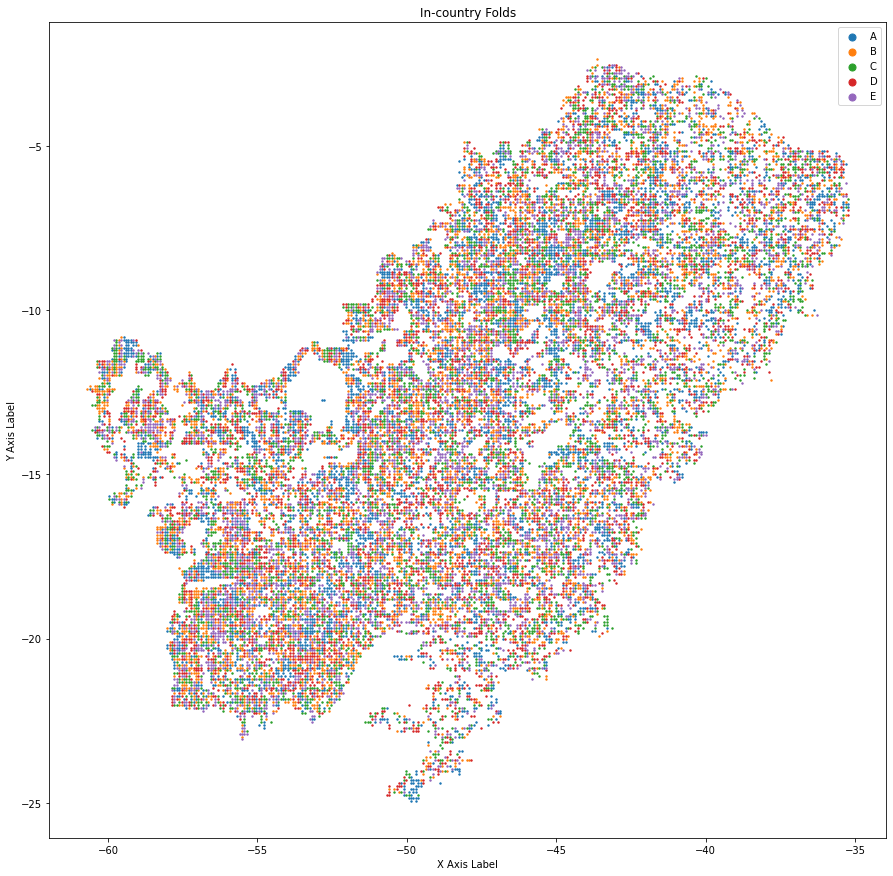

<Figure size 432x288 with 0 Axes>

In [24]:
valid_folds = {f: locs[[i for i in incountry_folds[f]['test'] if i < len(locs)]] for f in FOLDS}

# Plotar os resultados
plot_splits(valid_folds, title='In-country Folds')
plt.savefig("folds.png")

In [25]:
countries =["brazil"]

In [26]:
def plot_counts(folds, countries, country_indices):
    '''
    Args
    - folds: dict, folds[f][split] is a np.array of indices
    - countries: list of str, names of countries
    - country_indices: dict, country (str) => np.array of indices
    '''
    counts = np.zeros([len(countries), len(FOLDS)], dtype=np.float32)
    for i, country in enumerate(countries):
        idxs = country_indices[country]
        for j, f in enumerate(FOLDS):
            counts[i, j] = len(np.intersect1d(folds[f]['test'], idxs))
    counts /= np.sum(counts, axis=1, keepdims=True)
    folds_df = pd.DataFrame(data=counts, columns=FOLDS, index=countries)

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    folds_df.plot.barh(ax=ax, stacked=True, width=0.8)
    ax.set_xlabel('fraction')
    fig.tight_layout()
    

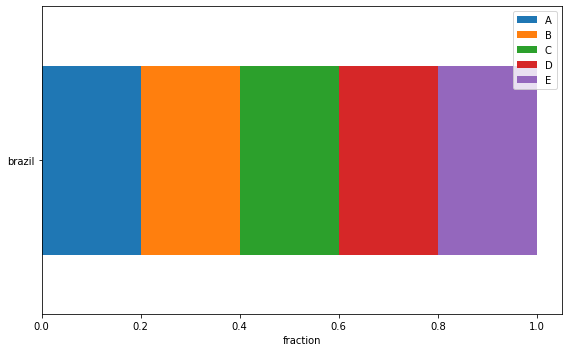

In [27]:
plot_counts(folds=incountry_folds,
            countries=values,
            country_indices=country_indices)

# as a sanity check, each country in `ooc_folds` should have a single solid color
# plot_counts(folds=ooc_folds,
#             countries=dataset_constants.DHS_COUNTRIES,
#             country_indices=country_indices)

plt.savefig("ali25.png")

## Urban v. Rural

In [28]:
def get_urban_rural_indices(locs, loc_dict):
    '''
    Args
    - locs: np.array, shape [N, 2]
    - loc_dict: dict, maps (lat, lon) => dict of info

    Returns
    - urban_indices: np.array, shape [num_urban]
    - rural_indices: np.array, shape [num_rural]
    '''
    urban_indices = []
    rural_indices = []

    for i, loc in enumerate(locs):
        loc = tuple(loc)
        if loc_dict[loc]['urban'] == 0:
            rural_indices.append(i)
        else:
            urban_indices.append(i)
    urban_indices = np.asarray(urban_indices)
    rural_indices = np.asarray(rural_indices)
    print('num urban: {}\t num rural: {}'.format(len(urban_indices), len(rural_indices)))
    return urban_indices, rural_indices

urban_indices, rural_indices = get_urban_rural_indices(locs, loc_dict)

KeyError: 'urban'

# Data Analysis by Country

In [29]:
pprint(COUNTRIES, compact=True)

YEARS = sorted(df['year'].unique())
pprint(YEARS, compact=True)

['Brazil']
[2010]


## Size

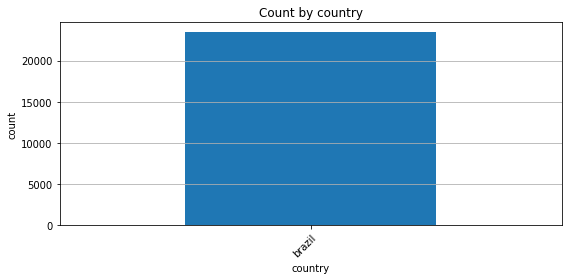

In [30]:
def plot_countries_by_size(df):
    counts = df.groupby('country').size()
    counts.sort_values(inplace=True, ascending=False)

    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    counts.to_frame().plot(kind='bar', ax=ax, legend=None)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right',
             rotation_mode='anchor')
    ax.set_ylabel('count')
    ax.set_title('Count by country')
    ax.grid(True, axis='y')
    fig.tight_layout()
    plt.show()

plot_countries_by_size(df)


In [31]:
with pd.option_context('display.max_rows', 100):
    counts_series = df.groupby(['country', 'year']).size().rename('count')
    display(counts_series.to_frame())

,,count
country,year,
brazil,2010,23477


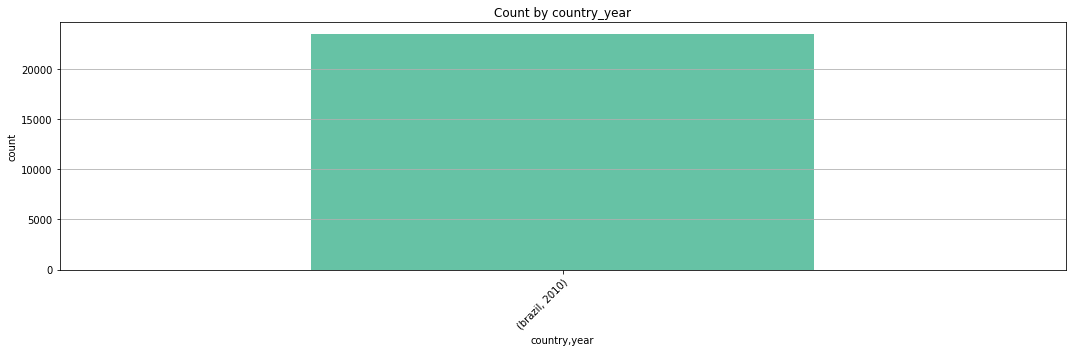

In [32]:
def plot_cy_by_size(df, country_year_colors):
    fig, ax = plt.subplots(1, 1, figsize=[15, 5])
    df.groupby(['country', 'year']).size().plot(
        kind='bar', ax=ax, color=country_year_colors)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax.set_ylabel('count')
    ax.set_title('Count by country_year')
    ax.grid(True, axis='y')
    fig.tight_layout()
    plt.show()

country_year_index = df.groupby(['country', 'year']).size().index
CMAP_FN = plt.cm.get_cmap('Set2')
COUNTRY_YEAR_COLORS = [CMAP_FN.colors[i % 8] for i in country_year_index.codes[0]]
plot_cy_by_size(df, COUNTRY_YEAR_COLORS)

## Wealthpooled

In [35]:
# df_country = df.groupby('country')['wealthpooled'].describe()
# colordisplay(df_country)
# df_country.to_csv('/home/sagemaker-user/reproducible/data/processed/surveys.csv')


In [36]:
# boxplot_df(df, y='wealthpooled', by='country',
#            figsize=(8, 5), ylabel='wealthpooled', 
#            title='Wealthpooled distribution by country', 
#            colors=['lightblue' for _ in values])

# boxplot_df(df, y='wealthpooled', by='year',
#            figsize=(4, 4), ylabel='wealthpooled',
#            title='Wealthpooled distribution by year',
#            colors=['lightblue' for _ in YEARS])

# boxplot_df(df, y='wealthpooled', by=['country', 'year'],
#            figsize=(16, 6), ylabel='wealthpooled',
#            title='Wealthpooled distribution by country_year',
#            colors=COUNTRY_YEAR_COLORS)

## Urban v. Rural

In [43]:
# def plot_urban_rural(df, by, color=None, title=None, figsize=(10, 5)):
#     '''
#     Args
#     - df: pd.DataFrame
#     - by: str or list of str, column(s) to group by
#     - color: list of colors
#     - title: str
#     '''
#     fig, ax = plt.subplots(1, 1, figsize=figsize)
#     urban_series = df.groupby(by)['urban'].mean()
#     if color is None:
#         urban_series.plot(kind='bar', ax=ax, width=0.8)
#     else:
#         urban_series.plot(kind='bar', ax=ax, color=color, width=0.8)
#     plt.setp(ax.get_xticklabels(), rotation=60, ha='right',
#              rotation_mode='anchor')
#     if title is not None:
#         ax.set_title(title)
#     ax.grid(True, axis='y')
#     ax.set_ylabel('fraction urban')
#     fig.tight_layout()

In [44]:
# plot_urban_rural(df, by='country', title='Urban fraction by country', figsize=(8, 5))

In [45]:
# plot_urban_rural(df, by=['country', 'year'],
#                  color=COUNTRY_YEAR_COLORS,
#                  title='Urban fraction by country_year',
#                  figsize=(17, 6))

## Nightlights

In [47]:
# # !!
# import matplotlib.pyplot as plt

# def boxplot_df(df, y, by, figsize=None, ylabel=None, title=None, colors=None, ax=None):
#     '''Creates a box-and-whisker plot from a DataFrame.

#     Args
#     - df: pd.DataFrame, contains columns from `y` and `by`
#     - y: str, name of a column in `df` for the y-axis
#     - by: str or list of str, names of columns in `df` to group by
#     - figsize: list of float, [width, height], in inches
#     - ylabel: str
#     - title: str
#     - colors: list of matplotlib colors, one per group after grouping by `by`
#     - ax: matplotlib.axes.Axes
#     '''
#     fig = None
#     if ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=figsize)
#     bplot = df.boxplot(y, by=by, ax=ax, grid=False, patch_artist=True,
#                        return_type='dict', widths=0.8)
#     if colors is not None:
#         for i, patch in enumerate(bplot[y]['boxes']):
#             patch.set_facecolor(colors[i])
#     ax.grid(True, axis='y')
#     plt.setp(ax.get_xticklabels(), rotation=60, ha='right',
#              rotation_mode='anchor')
#     ax.set_ylabel(ylabel)
#     ax.set_title(title)
#     ax.get_figure().suptitle(None)
#     if fig is not None:
#         fig.tight_layout()

# # Verificar o comprimento original do DataFrame e da nova máscara
# print(f"Comprimento original do DataFrame: {len(df)}")
# print(f"Comprimento da nova máscara: {len(dmsp_mask_novo)}")

# # Aplicar a nova máscara ao DataFrame
# filtered_df = df[dmsp_mask_novo]

# # Verificar o tamanho dos dados filtrados
# print(f"Tamanho do DataFrame filtrado: {len(filtered_df)}")

# # Verificar se as colunas 'country' e 'year' estão presentes e consistentes
# print(f"Colunas presentes: {filtered_df.columns}")

# # Verificar se há valores ausentes nas colunas 'country' e 'year'
# missing_values = filtered_df[['country', 'year']].isnull().sum()
# print(f"Valores ausentes em 'country': {missing_values['country']}")
# print(f"Valores ausentes em 'year': {missing_values['year']}")

# # Verificar os grupos únicos em 'country' e 'year'
# unique_countries = filtered_df['country'].unique()
# unique_years = filtered_df['year'].unique()
# print(f"Países únicos: {unique_countries}")
# print(f"Anos únicos: {unique_years}")

# # Chamar a função boxplot_df com verificações
# boxplot_df(filtered_df, y='nl_center', by=['country', 'year'],
#            figsize=(5, 6), ylabel='nl_center',
#            title='Center DMSP distribution by country/year',
#            colors=COUNTRY_YEAR_COLORS)

# boxplot_df(filtered_df, y='nl_mean', by=['country', 'year'],
#            figsize=(5, 6), ylabel='nl_mean',
#            title='Mean DMSP distribution by country/year',
#            colors=COUNTRY_YEAR_COLORS)

In [48]:
# import matplotlib.pyplot as plt

# def boxplot_df(df, y, by, figsize=None, ylabel=None, title=None, colors=None, ax=None):
#     '''Creates a box-and-whisker plot from a DataFrame.

#     Args
#     - df: pd.DataFrame, contains columns from `y` and `by`
#     - y: str, name of a column in `df` for the y-axis
#     - by: str or list of str, names of columns in `df` to group by
#     - figsize: list of float, [width, height], in inches
#     - ylabel: str
#     - title: str
#     - colors: list of matplotlib colors, one per group after grouping by `by`
#     - ax: matplotlib.axes.Axes
#     '''
#     fig = None
#     if ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=figsize)
#     bplot = df.boxplot(y, by=by, ax=ax, grid=False, patch_artist=True,
#                        return_type='dict', widths=0.8)
#     if colors is not None:
#         for i, patch in enumerate(bplot[y]['boxes']):
#             patch.set_facecolor(colors[i])
#     ax.grid(True, axis='y')
#     plt.setp(ax.get_xticklabels(), rotation=60, ha='right',
#              rotation_mode='anchor')
#     ax.set_ylabel(ylabel)
#     ax.set_title(title)
#     ax.get_figure().suptitle(None)
#     if fig is not None:
#         fig.tight_layout()

# # Verificar o tamanho dos dados filtrados
# filtered_df = df[dmsp_mask]
# print(f"Tamanho do DataFrame filtrado: {len(filtered_df)}")

# # Verificar se as colunas 'country' e 'year' estão presentes e consistentes
# print(f"Colunas presentes: {filtered_df.columns}")

# # Verificar se há valores ausentes nas colunas 'country' e 'year'
# missing_values = filtered_df[['country', 'year']].isnull().sum()
# print(f"Valores ausentes em 'country': {missing_values['country']}")
# print(f"Valores ausentes em 'year': {missing_values['year']}")

# # Verificar os grupos únicos em 'country' e 'year'
# unique_countries = filtered_df['country'].unique()
# unique_years = filtered_df['year'].unique()
# print(f"Países únicos: {unique_countries}")
# print(f"Anos únicos: {unique_years}")

# # Chamar a função boxplot_df com verificações
# boxplot_df(filtered_df, y='nl_center', by=['country', 'year'],
#            figsize=(5, 6), ylabel='nl_center',
#            title='Center DMSP distribution by country/year',
#            colors=COUNTRY_YEAR_COLORS)

# boxplot_df(filtered_df, y='nl_mean', by=['country', 'year'],
#            figsize=(5, 6), ylabel='nl_mean',
#            title='Mean DMSP distribution by country/year',
#            colors=COUNTRY_YEAR_COLORS)

In [50]:
# # !!
# boxplot_df(filtered_df, y='nl_center', by=['country', 'year'],
#            figsize=(5, 6), ylabel='nl_center',
#            title='Center DMSP distribution by country/year',
#            colors=COUNTRY_YEAR_COLORS)

# boxplot_df(filtered_df, y='nl_mean', by=['country', 'year'],
#            figsize=(5, 6), ylabel='nl_mean',
#            title='Mean DMSP distribution by country/year',
#            colors=COUNTRY_YEAR_COLORS)

In [51]:
# boxplot_df(df[dmsp_mask], y='nl_center', by=['country', 'year'],
#            figsize=(5, 6), ylabel='nl_center',}
#            title='Center DMSP distribution by country/year',
#            colors=COUNTRY_YEAR_COLORS)

# boxplot_df(df[dmsp_mask], y='nl_mean', by=['country', 'year'],
#            figsize=(5, 6), ylabel='nl_mean',
#            title='Mean DMSP distribution by country/year',
#            colors=COUNTRY_YEAR_COLORS)

## Households

# Data Analysis by Split

## Wealthpooled

Removendo 34 índices inválidos no fold A, split train.
Removendo 8 índices inválidos no fold A, split val.
Removendo 2 índices inválidos no fold A, split test.
Removendo 16 índices inválidos no fold B, split train.
Removendo 20 índices inválidos no fold B, split val.
Removendo 8 índices inválidos no fold B, split test.
Removendo 20 índices inválidos no fold C, split train.
Removendo 4 índices inválidos no fold C, split val.
Removendo 20 índices inválidos no fold C, split test.
Removendo 30 índices inválidos no fold D, split train.
Removendo 10 índices inválidos no fold D, split val.
Removendo 4 índices inválidos no fold D, split test.
Removendo 32 índices inválidos no fold E, split train.
Removendo 2 índices inválidos no fold E, split val.
Removendo 10 índices inválidos no fold E, split test.


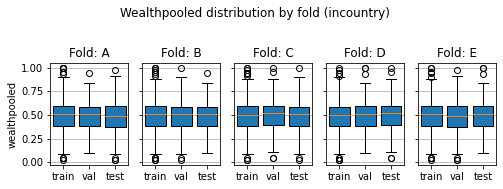

In [52]:
# !!
def plot_labels_by_fold(labels, folds, title=None):
    '''
    Args
    - labels: np.array, shape [N], type float32
    - folds: dict, folds[f][split] is a np.array of indices
    - title: str, figure title
    '''
    fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(7, 2.5))
    for f, ax in zip(FOLDS, axs.flat):
        data = []
        for split in SPLITS:
            indices = folds[f][split]
            # Remover índices inválidos
            valid_indices = indices[indices < len(labels)]
            if len(valid_indices) < len(indices):
                print(f"Removendo {len(indices) - len(valid_indices)} índices inválidos no fold {f}, split {split}.")
            data.append(labels[valid_indices])
        ax.boxplot(data, patch_artist=True, widths=0.8)

        # add x-tick labels
        plt.setp(ax, xticks=[1, 2, 3], xticklabels=SPLITS)

        ax.grid(True, axis='y')
        ax.set_title(f'Fold: {f}')

    axs[0].set_ylabel('wealthpooled')
    if title is not None:
        fig.suptitle(title, y=1.03)
    fig.tight_layout()

# Plotar com a correção para índices inválidos
plot_labels_by_fold(labels, incountry_folds, title='Wealthpooled distribution by fold (incountry)')

In [53]:
# def plot_labels_by_fold(labels, folds, title=None):
#     '''
#     Args
#     - labels: np.array, shape [N], type float32
#     - folds: dict, folds[f][split] is a np.array of indices
#     - title: str, figure title
#     '''
#     fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(7, 2.5))
#     for f, ax in zip(FOLDS, axs.flat):
#         data = [labels[folds[f][split]] for split in SPLITS]
#         ax.boxplot(data, patch_artist=True, widths=0.8)

#         # add x-tick labels
#         plt.setp(ax, xticks=[1, 2, 3], xticklabels=SPLITS)

#         ax.grid(True, axis='y')
#         ax.set_title(f'Fold: {f}')

#     axs[0].set_ylabel('wealthpooled')
#     if title is not None:
#         fig.suptitle(title, y=1.03)
#     fig.tight_layout()
    
# plot_labels_by_fold(labels, incountry_folds, title='Wealthpooled distribution by fold (incountry)')

Removendo 34 índices inválidos no fold A, split train.
Removendo 8 índices inválidos no fold A, split val.
Removendo 2 índices inválidos no fold A, split test.
Removendo 16 índices inválidos no fold B, split train.
Removendo 20 índices inválidos no fold B, split val.
Removendo 8 índices inválidos no fold B, split test.
Removendo 20 índices inválidos no fold C, split train.
Removendo 4 índices inválidos no fold C, split val.
Removendo 20 índices inválidos no fold C, split test.
Removendo 30 índices inválidos no fold D, split train.
Removendo 10 índices inválidos no fold D, split val.
Removendo 4 índices inválidos no fold D, split test.
Removendo 32 índices inválidos no fold E, split train.
Removendo 2 índices inválidos no fold E, split val.
Removendo 10 índices inválidos no fold E, split test.


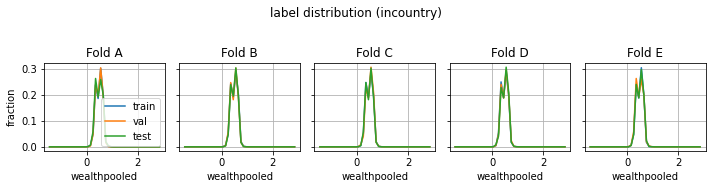

In [54]:
# !!
def plot_label_hists(labels, folds, title=None):
    '''
    Args
    - labels: np.array, shape [N], type float32
    - folds: dict, folds[f][split] is a np.array of indices
    - title: str, figure title
    '''
    fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(10, 2.5))
    LABEL_BIN_EDGES = np.arange(-1.5, 3.0, 0.1)
    bin_centers = np.convolve(LABEL_BIN_EDGES, [.5, .5], mode='valid')

    for f, ax in zip(FOLDS, axs.flat):
        for split in SPLITS:
            indices = folds[f][split]
            # Remover índices inválidos
            valid_indices = indices[indices < len(labels)]
            if len(valid_indices) < len(indices):
                print(f"Removendo {len(indices) - len(valid_indices)} índices inválidos no fold {f}, split {split}.")
            
            label_hist, _ = np.histogram(a=labels[valid_indices], bins=LABEL_BIN_EDGES)
            ax.plot(bin_centers, label_hist / np.sum(label_hist), label=split)
        ax.set_xlabel('wealthpooled')
        ax.set_title(f'Fold {f}')
        ax.grid(True)

    axs[0].legend()
    axs[0].set_ylabel('fraction')
    if title is not None:
        fig.suptitle(title, y=1.03)
    fig.tight_layout()
    
plot_label_hists(labels, incountry_folds, title='label distribution (incountry)')

In [55]:
# def plot_label_hists(labels, folds, title=None):
#     '''
#     Args
#     - labels: np.array, shape [N], type float32
#     - folds: dict, folds[f][split] is a np.array of indices
#     - title: str, figure title
#     '''
#     fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(10, 2.5))
#     LABEL_BIN_EDGES = np.arange(-1.5, 3.0, 0.1)
#     bin_centers = np.convolve(LABEL_BIN_EDGES, [.5, .5], mode='valid')

#     for f, ax in zip(FOLDS, axs.flat):
#         for split in SPLITS:
#             label_hist, _ = np.histogram(a=labels[folds[f][split]], bins=LABEL_BIN_EDGES)
#             ax.plot(bin_centers, label_hist / np.sum(label_hist), label=split)
#         ax.set_xlabel('wealthpooled')
#         ax.set_title(f'Fold {f}')
#         ax.grid(True)

#     axs[0].legend()
#     axs[0].set_ylabel('fraction')
#     if title is not None:
#         fig.suptitle(title, y=1.03)
#     fig.tight_layout()
    
# plot_label_hists(labels, incountry_folds, title='label distribution (incountry)')

## Urban v. Rural

In [56]:
def plot_urban_by_fold(urban, folds, title=None):
    '''
    Args
    - urban: np.array, shape [N], type bool
    - folds: dict, folds[f][split] is a np.array of indices
    - title: str, figure title
    '''
    fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(7, 2.5))
    for f, ax in zip(FOLDS, axs.flat):
        data = [urban[folds[f][split]].mean() for split in SPLITS]
        ax.bar([0, 1, 2], data, width=0.8)

        # add x-tick labels
        plt.setp(ax, xticks=[0, 1, 2], xticklabels=SPLITS)

        ax.grid(True, axis='y')
        ax.set_title(f'Fold: {f}')

    axs[0].set_ylabel('urban fraction')
    if title is not None:
        fig.suptitle(title, y=1.03)
    fig.tight_layout()

In [58]:
# plot_urban_by_fold(df['urban'].values, incountry_folds, title='Urban/rural distribution by fold (incountry)')

## Nightlights

Removendo 152 índices inválidos no fold A, split train.
Removendo 57 índices inválidos no fold A, split val.
Removendo 33 índices inválidos no fold A, split test.
Removendo 125 índices inválidos no fold B, split train.
Removendo 60 índices inválidos no fold B, split val.
Removendo 57 índices inválidos no fold B, split test.
Removendo 149 índices inválidos no fold C, split train.
Removendo 33 índices inválidos no fold C, split val.
Removendo 60 índices inválidos no fold C, split test.
Removendo 150 índices inválidos no fold D, split train.
Removendo 59 índices inválidos no fold D, split val.
Removendo 33 índices inválidos no fold D, split test.
Removendo 150 índices inválidos no fold E, split train.
Removendo 33 índices inválidos no fold E, split val.
Removendo 59 índices inválidos no fold E, split test.


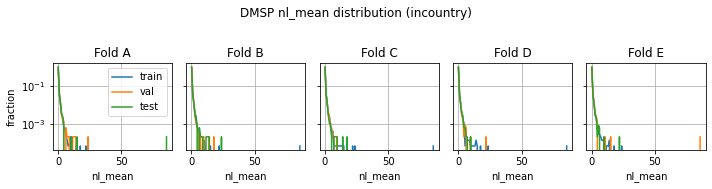

In [59]:
# !! 
def plot_nl_by_fold(df, folds, col, dmsp, title=None):
    '''
    Args
    - df: pd.DataFrame
    - folds: dict, folds[f][split] is a np.array of indices
    - col: str, one of ['nl_mean', 'nl_center']
    - dmsp: bool
    - title: str, figure title
    '''
    fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(10, 2.5))
    bin_edges = np.linspace(start=df[col].min() - 0.1, stop=df[col].max() + 0.1, num=100)
    bin_centers = np.convolve(bin_edges, [.5, .5], mode='valid')

    for f, ax in zip(FOLDS, axs.flat):
        for split in SPLITS:
            indices = folds[f][split]
            # Remover índices inválidos
            valid_indices = indices[indices < len(df)]
            if len(valid_indices) < len(indices):
                print(f"Removendo {len(indices) - len(valid_indices)} índices inválidos no fold {f}, split {split}.")
            
            if len(valid_indices) == 0:
                print(f"Nenhum índice válido encontrado no fold {f}, split {split}. Pulando...")
                continue

            nls_df = df.loc[valid_indices, [col, 'year']]
            if dmsp:
                nl_hist, _ = np.histogram(
                    nls_df.loc[nls_df['year'] < 2012, col],
                    bins=bin_edges)
            else:
                nl_hist, _ = np.histogram(
                    nls_df.loc[nls_df['year'] >= 2012, col],
                    bins=bin_edges)
            if np.sum(nl_hist) > 0:
                ax.plot(bin_centers, nl_hist / np.sum(nl_hist), label=split)
            else:
                print(f"Histograma vazio no fold {f}, split {split}. Pulando plotagem...")
        ax.set_xlabel(col)
        ax.set_yscale('log')
        ax.set_title(f'Fold {f}')
        ax.grid(True)

    axs[0].legend()
    axs[0].set_ylabel('fraction')
    if title is not None:
        fig.suptitle(title, y=1.03)
    fig.tight_layout()

plot_nl_by_fold(df, incountry_folds, col='nl_mean', dmsp=True, title='DMSP nl_mean distribution (incountry)')

Removendo 152 índices inválidos no fold A, split train.
Removendo 57 índices inválidos no fold A, split val.
Removendo 33 índices inválidos no fold A, split test.
Removendo 125 índices inválidos no fold B, split train.
Removendo 60 índices inválidos no fold B, split val.
Removendo 57 índices inválidos no fold B, split test.
Removendo 149 índices inválidos no fold C, split train.
Removendo 33 índices inválidos no fold C, split val.
Removendo 60 índices inválidos no fold C, split test.
Removendo 150 índices inválidos no fold D, split train.
Removendo 59 índices inválidos no fold D, split val.
Removendo 33 índices inválidos no fold D, split test.
Removendo 150 índices inválidos no fold E, split train.
Removendo 33 índices inválidos no fold E, split val.
Removendo 59 índices inválidos no fold E, split test.


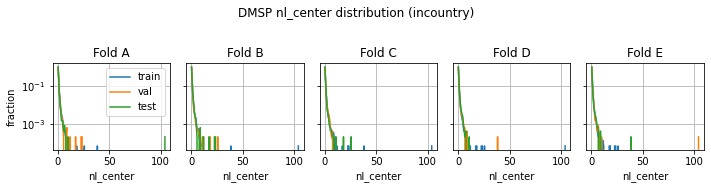

In [60]:
# !!
plot_nl_by_fold(df, incountry_folds, col='nl_center', dmsp=True, title='DMSP nl_center distribution (incountry)')

In [ ]:
# plot_nl_by_fold(df, incountry_folds, col='nl_center', dmsp=True, title='DMSP nl_center distribution (incountry)')

In [ ]:
# def plot_nl_by_fold(df, folds, col, dmsp, title=None):
#     '''
#     Args
#     - df: pd.DataFrame
#     - folds: dict, folds[f][split] is a np.array of indices
#     - col: str, one of ['nl_mean', 'nl_center']
#     - dmsp: bool
#     - title: str, figure title
#     '''
#     fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(10, 2.5))
#     bin_edges = np.linspace(start=df[col].min()-0.1, stop=df[col].max()+0.1, num=100)
#     bin_centers = np.convolve(bin_edges, [.5, .5], mode='valid')

#     for f, ax in zip(FOLDS, axs.flat):
#         for split in SPLITS:
#             nls_df = df.loc[folds[f][split], [col, 'year']]
#             if dmsp:
#                 nl_hist, _ = np.histogram(
#                     nls_df.loc[nls_df['year'] < 2012, col],
#                     bins=bin_edges)
#             else:
#                 nl_hist, _ = np.histogram(
#                     nls_df.loc[nls_df['year'] >= 2012, col],
#                     bins=bin_edges)
#             ax.plot(bin_centers, nl_hist / np.sum(nl_hist), label=split)
#         ax.set_xlabel(col)
#         ax.set_yscale('log')
#         ax.set_title(f'Fold {f}')
#         ax.grid(True)

#     axs[0].legend()
#     axs[0].set_ylabel('fraction')
#     if title is not None:
#         fig.suptitle(title, y=1.03)
#     fig.tight_layout()
# plot_nl_by_fold(df, incountry_folds, col='nl_mean', dmsp=True, title='DMSP nl_mean distribution (incountry)')

Removendo 152 índices inválidos no fold A, split train.
Removendo 57 índices inválidos no fold A, split val.
Removendo 33 índices inválidos no fold A, split test.
Removendo 125 índices inválidos no fold B, split train.
Removendo 60 índices inválidos no fold B, split val.
Removendo 57 índices inválidos no fold B, split test.
Removendo 149 índices inválidos no fold C, split train.
Removendo 33 índices inválidos no fold C, split val.
Removendo 60 índices inválidos no fold C, split test.
Removendo 150 índices inválidos no fold D, split train.
Removendo 59 índices inválidos no fold D, split val.
Removendo 33 índices inválidos no fold D, split test.
Removendo 150 índices inválidos no fold E, split train.
Removendo 33 índices inválidos no fold E, split val.
Removendo 59 índices inválidos no fold E, split test.


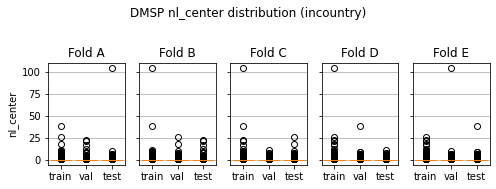

In [61]:
# !!
def nl_boxplots_by_fold(df, folds, col, dmsp, title=None):
    '''
    Args
    - df: pd.DataFrame
    - folds: dict, folds[f][split] is a np.array of indices
    - col: str, one of ['nl_mean', 'nl_center']
    - dmsp: bool
    - title: str, figure title
    '''
    fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(7, 2.5))
    for f, ax in zip(FOLDS, axs.flat):
        data = []
        for split in SPLITS:
            indices = folds[f][split]
            # Remover índices inválidos
            valid_indices = indices[indices < len(df)]
            if len(valid_indices) < len(indices):
                print(f"Removendo {len(indices) - len(valid_indices)} índices inválidos no fold {f}, split {split}.")
            
            if len(valid_indices) == 0:
                print(f"Nenhum índice válido encontrado no fold {f}, split {split}. Pulando...")
                continue

            nls_df = df.loc[valid_indices, [col, 'year']]
            if dmsp:
                data.append(nls_df.loc[nls_df['year'] < 2012, col])
            else:
                data.append(nls_df.loc[nls_df['year'] >= 2012, col])
        if data:
            ax.boxplot(data, patch_artist=True, widths=0.8)

        # add x-tick labels
        plt.setp(ax, xticks=[1, 2, 3], xticklabels=SPLITS)

        ax.set_title(f'Fold {f}')
        ax.grid(True, axis='y')

    axs[0].set_ylabel(col)
    if title is not None:
        fig.suptitle(title, y=1.03)
    fig.tight_layout()

nl_boxplots_by_fold(df, incountry_folds, col='nl_center', dmsp=True, title='DMSP nl_center distribution (incountry)')

In [ ]:
# def nl_boxplots_by_fold(df, folds, col, dmsp, title=None):
#     '''
#     Args
#     - df: pd.DataFrame
#     - folds: dict, folds[f][split] is a np.array of indices
#     - col: str, one of ['nl_mean', 'nl_center']
#     - dmsp: bool
#     - title: str, figure title
#     '''
#     fig, axs = plt.subplots(nrows=1, ncols=5, sharey=True, figsize=(7, 2.5))
#     for f, ax in zip(FOLDS, axs.flat):
#         data = []
#         for split in SPLITS:
#             nls_df = df.loc[folds[f][split], [col, 'year']]
#             if dmsp:
#                 data.append(nls_df.loc[nls_df['year'] < 2012, col])
#             else:
#                 data.append(nls_df.loc[nls_df['year'] >= 2012, col])
#         ax.boxplot(data, patch_artist=True, widths=0.8)

#         # add x-tick labels
#         plt.setp(ax, xticks=[1, 2, 3], xticklabels=SPLITS)

#         ax.set_title(f'Fold {f}')
#         ax.grid(True, axis='y')

#     axs[0].set_ylabel(col)
#     if title is not None:
#         fig.suptitle(title, y=1.03)
#     fig.tight_layout()
    
# nl_boxplots_by_fold(df, incountry_folds, col='nl_center', dmsp=True, title='DMSP nl_center distribution (incountry)')

# All-Zero NL

In [63]:
# # !!
# # Verificar o comprimento da máscara original e do DataFrame
# print(f"Comprimento original do DataFrame: {len(df)}")
# print(f"Comprimento da máscara: {len(dmsp_mask)}")

# # Criar uma nova máscara baseada no DataFrame atual
# dmsp_mask_novo = dmsp_mask[:len(df)]

# # Verificar se a nova máscara tem o mesmo comprimento do DataFrame
# print(f"Comprimento da nova máscara: {len(dmsp_mask_novo)}")

# # Criar o DataFrame zeros_df usando a nova máscara
# zeros_df = pd.DataFrame({
#     'DMSP': [DMSP_ZERO,
#              df.loc[dmsp_mask_novo, 'nl_center'].min(),
#              df.loc[dmsp_mask_novo, 'nl_mean'].min()],
# }, index=['True 0', 'min nls_center', 'min nls_mean'])

# with pd.option_context('precision', 9):
#     display(zeros_df)

In [64]:
# MEANS = dataset_constants.MEANS_DICT[DATASET]
# STD_DEVS = dataset_constants.STD_DEVS_DICT[DATASET]

# DMSP_ZERO = np.float32(-MEANS['DMSP'] / STD_DEVS['DMSP'])

# zeros_df = pd.DataFrame({
#     'DMSP': [DMSP_ZERO,
#              df.loc[dmsp_mask, 'nl_center'].min(),
#              df.loc[dmsp_mask, 'nl_mean'].min()],
# }, index=['True 0', 'min nls_center', 'min nls_mean'])

# with pd.option_context('precision', 9):
#     display(zeros_df)

In [66]:
# dmsp_zero_mask = dmsp_mask & (nls_mean == DMSP_ZERO)
# zeros_label_df = pd.DataFrame({
#     'label, when DMSP is all-zero': labels[dmsp_zero_mask]
# })
# display(zeros_label_df.describe().T)

# fig, ax = plt.subplots(1, 1, figsize=(4, 3))
# ax.hist(labels[dmsp_zero_mask], bins=50)
# ax.set(xlabel='label', ylabel='count', title='Histogram of labels when DMSP is all-0')
# ax.grid(True)
# fig.tight_layout()

In [68]:
# # !!
# # Verificar o comprimento da máscara original e do DataFrame
# print(f"Comprimento original do DataFrame: {len(df)}")
# print(f"Comprimento da máscara: {len(dmsp_zero_mask)}")

# # Ajustar a máscara para ter o mesmo comprimento do DataFrame
# if len(dmsp_zero_mask) != len(df):
#     dmsp_zero_mask = dmsp_zero_mask[:len(df)]

# # Verificar se a nova máscara tem o mesmo comprimento do DataFrame
# print(f"Comprimento da nova máscara: {len(dmsp_zero_mask)}")

# # Adicionar a nova máscara ao DataFrame
# df['zero_nl'] = dmsp_zero_mask

# # Calcular os contagens e frações
# zero_nl_counts = df.groupby('country')['zero_nl'].sum().astype(int)
# zero_nl_frac = zero_nl_counts / df.groupby('country').size()

# # Plotar os gráficos
# fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 5))
# zero_nl_counts.plot.barh(width=0.8, ax=axs[0], grid=True)
# zero_nl_frac.plot.barh(width=0.8, ax=axs[1], grid=True)
# axs[0].set_xlabel('count')
# axs[1].set_xlabel('fraction')
# fig.suptitle('All-0 DMSP Nightlights', y=1.02)
# fig.tight_layout()

In [69]:
# df['zero_nl'] = dmsp_zero_mask
# zero_nl_counts = df.groupby('country')['zero_nl'].sum().astype(int)
# zero_nl_frac = zero_nl_counts / df.groupby('country').size()

# fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 5))
# zero_nl_counts.plot.barh(width=0.8, ax=axs[0], grid=True)
# zero_nl_frac.plot.barh(width=0.8, ax=axs[1], grid=True)
# axs[0].set_xlabel('count')
# axs[1].set_xlabel('fraction')
# fig.suptitle('All-0 DMSP Nightlights', y=1.02)
# fig.tight_layout()

# Visualize Images

In [70]:
import batchers.batcher1 as batcher
tfrecord_paths = np.asarray(batcher.get_tfrecord_paths(dataset=DATASET, split='all'))
K = 1

brazil_2010
23675
23675


In [71]:
def get_images(tfrecord_paths):
    '''
    Args
    - tfrecord_paths: list of str, length N <= 32, paths of TFRecord files

    Returns: np.array, shape [N, 224, 224, 8], type float32
    '''
    init_iter, batch_op = batcher.Batcher(
        tfrecord_files=tfrecord_paths,
        dataset=DATASET,
        batch_size=32,
        ls_bands='ms',
        nl_band='merge',
        label_name='income',
        shuffle=False,
        augment=False,
        negatives='zero',
        normalize=True).get_batch()
    with tf.Session() as sess:
        sess.run(init_iter)
        images = sess.run(batch_op['images'])
    return images

In [72]:
def plot_images_by_wealth(indices, images, labels, years, locs,
                          country_labels, countries, title_str):
    '''
    Args
    - indices: np.array, shape [K], type int64
    - images: np.array, shape [K, 224, 224, 8]
    - labels: np.array, shape [N], type float32
    - years: np.array, shape [N], type int32
    - locs: np.array, shape [N, 2], type float32
    - country_labels: np.array, shape [N], type int32
    - countries: list of str, names of countries corresponding to country labels
    - title_str: format str, contains variables [k, label, country, year, lat, lon]
    '''
    for k, i in enumerate(indices):
        img = images[k]
        label, year, loc = labels[i], years[i], locs[i]
        lat, lon = tuple(loc)
        country = countries[country_labels[i]]
        title = title_str.format(k=k+1, label=label, country=country, year=year, lat=lat, lon=lon)
        print(title)
        band_order = list(BAND_ORDER)  # make a copy
        band_order[-1] = 'DMSP' if year < 2012 else 'VIIRS'
        plot_image_by_band(img, band_order, nrows=1, title=title, rgb='merge')

## Random Sampling



Instructions for updating:
Use `for ... in dataset:` to iterate over a dataset. If using `tf.estimator`, return the `Dataset` object directly from your input function. As a last resort, you can use `tf.compat.v1.data.make_initializable_iterator(dataset)`.
income: 0.637966, loc = Brazil 2010 (-12.887725, -58.990913)


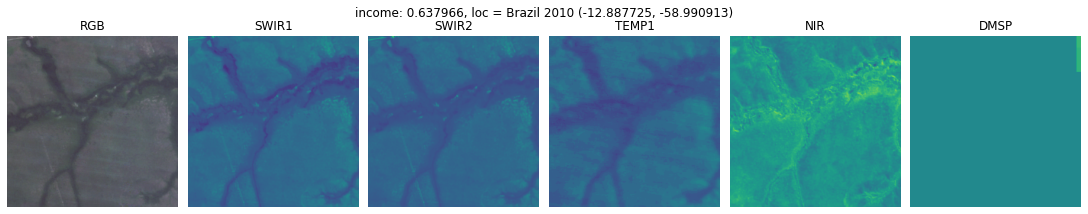

In [73]:
import random
index_random = random.randrange(len(labels))
indices = [np.argsort(labels)[::-1][index_random]]
images = get_images(tfrecord_paths[indices])
title_str = 'income: {label:.06f}, loc = {country} {year} ({lat:.06f}, {lon:.06f})'
plot_images_by_wealth(indices, images, labels, years, locs,
                      country_labels=country_labels,
                      countries=COUNTRIES,
                      title_str=title_str)

